In [3]:
import pandas as pd 
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, roc_auc_score, recall_score, confusion_matrix

In [4]:
data = load_breast_cancer()

X = data.data
y = data.target

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.25)

In [23]:
estimators = range(1, 1001, 50)
accuracies = []
precisions = [] 
recalls = []
auc_scores = [] 

for estimator in estimators:
    model = RandomForestClassifier(n_estimators=estimator, random_state=42)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    accuracies.append(accuracy_score(y_pred=y_pred, y_true=y_test))
    precisions.append(precision_score(y_pred=y_pred, y_true=y_test))
    recalls.append(recall_score(y_pred=y_pred, y_true=y_test))
    auc_scores.append(roc_auc_score(y_test, y_pred_proba))

In [35]:
def plot_metric(metric_list: list[float], estimator_list: list[int], metric_name: str, color: str):
    plt.title(f"Evaluating Random Forest classifier {metric_name} over n_estimators from 1 to 1000")
    plt.xlabel("Number of estimators")
    plt.ylabel(f"{metric_name}")
    plt.plot(estimator_list, metric_list, marker="o", color=f"{color}")
    plt.show()

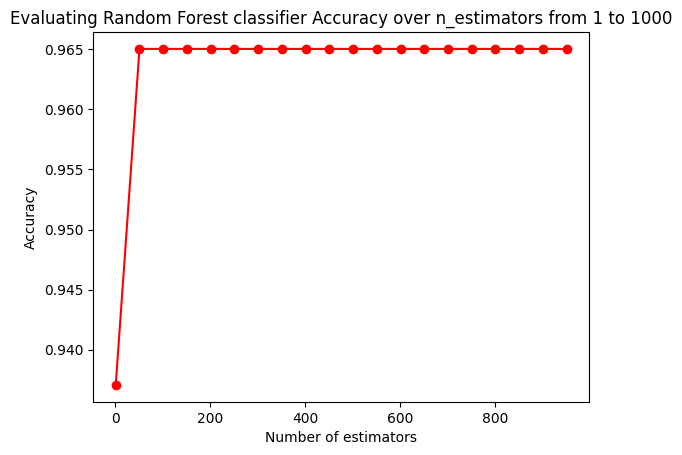

In [36]:
plot_metric(accuracies, estimators, "Accuracy", "red")

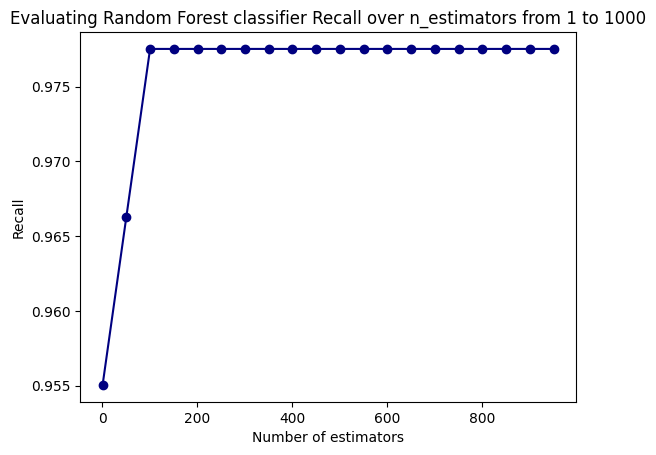

In [37]:
plot_metric(recalls, estimators, "Recall", "navy")

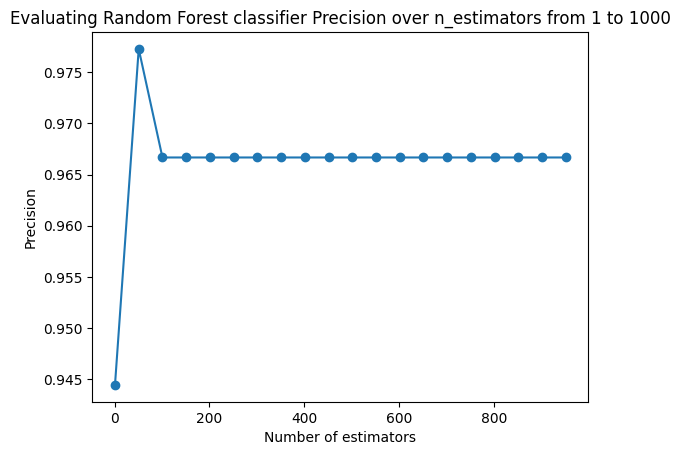

In [32]:
plot_metric(precisions, estimators, "Precision")

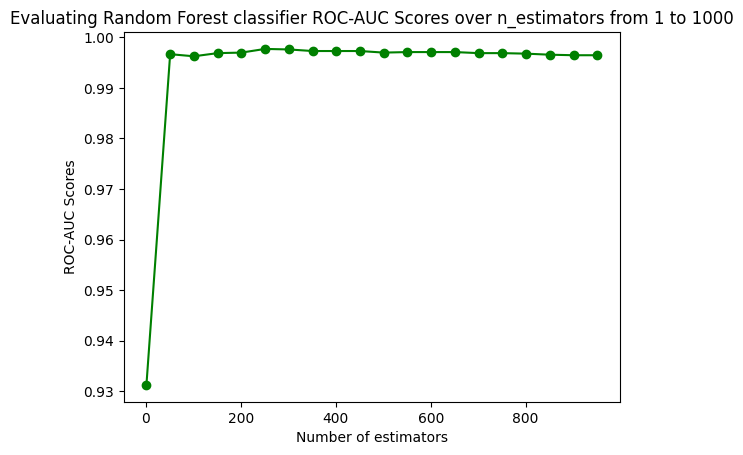

In [38]:
plot_metric(auc_scores, estimators, "ROC-AUC Scores", "green")